In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as plt
import seaborn as sns

**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
**Sibling** = brother, sister, stepbrother, stepsister
**Spouse** = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

## Preprocessing

---
TBD:
1. Попробовать сгруппировать (SibSp и Parch) в общую колонку с количеством родственников (family_count) на корабле. Возможно это даст лучшее качество.
2. Decision tree
3. Random forest
4. Gradient boosting
---

In [2]:
datapath = '/home/sidyaniv/Desktop/projects/kaggle_competitions/titanic/dataset/titanic'
gender_submission_name = 'gender_submission.csv'
test_name = 'test.csv'
train_name = 'train.csv'

target_data = pd.read_csv(os.path.join(datapath, gender_submission_name), index_col='PassengerId')
test_data = pd.read_csv(os.path.join(datapath, test_name), index_col='PassengerId')
train_data  = pd.read_csv(os.path.join(datapath, train_name), index_col='PassengerId')

test_data = pd.merge(test_data, target_data, left_index=True, right_index=True)

In [3]:
# Age ~20% пропусков
# 1-ый способ. Заменим пропуски в возрасте на медианный возраст по всей выборке
# median_age = train_data['Age'].median()
# train_data['Age'].fillna(median_age, inplace=True)
# test_data['Age'].fillna(median_age, inplace=True)

# 2-ой способ. Заменим пропуски на медианный возраст по группам
train_data['Age'] = train_data.groupby(['Pclass'] )['Age'].transform(lambda x: x.fillna(x.median()))
test_data['Age'] = test_data.groupby(['Pclass'] )['Age'].transform(lambda x: x.fillna(x.median()))

In [4]:
# Rename columns
rename = {'SibSp': 'br_sister_partner', 'Parch': 'parents_childs', 
          'Fare': 'ticket_cost', 'Embarked': 'port_name'}
train_data.rename(columns=rename, inplace=True)
test_data.rename(columns=rename, inplace=True)

# Drop columns
useless_names = ['Name', 'Ticket', 'Cabin']     # Удаляем Cabin так как она почти пустая. Остальное - не нужно

train_data.drop(columns=useless_names, inplace=True)
test_data.drop(columns=useless_names, inplace=True)

In [5]:
# port_name ~ <1%
# Заменим на моду по всем объектам
moda_port_name = train_data['port_name'].mode().item()
train_data['port_name'].fillna(moda_port_name, inplace=True)
test_data['port_name'].fillna(moda_port_name, inplace=True)

# test_data ~ <1%
median_ticket_cost = train_data['ticket_cost'].median()
train_data['ticket_cost'].fillna(median_ticket_cost, inplace=True)
test_data['ticket_cost'].fillna(median_ticket_cost, inplace=True)

/tmp/ipykernel_31934/1894081201.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['port_name'].fillna(moda_port_name, inplace=True)
/tmp/ipykernel_31934/1894081201.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [6]:
train_data['family_num'] = train_data['br_sister_partner'] + train_data['parents_childs']
test_data['family_num'] = test_data['br_sister_partner'] + test_data['parents_childs']

## Визуализации
Посмотрим на данные на графиках

/tmp/ipykernel_31934/3466744484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_data, x='Sex',  kind='count', palette = custom_colors)
/tmp/ipykernel_31934/3466744484.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x='Sex',  kind='count', palette = custom_colors)
/tmp/ipykernel_31934/3466744484.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x = 'Pclass', hue='Sex', kind='count', palette = custom_colors)


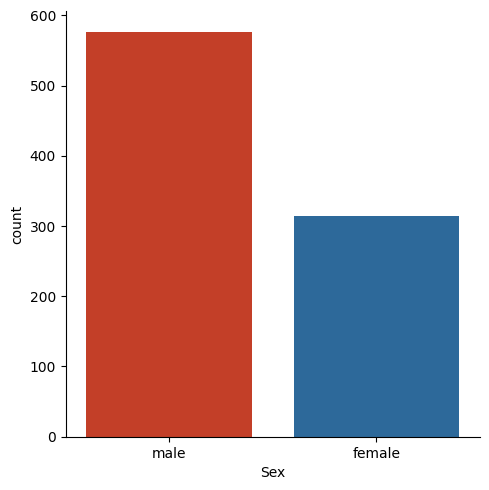

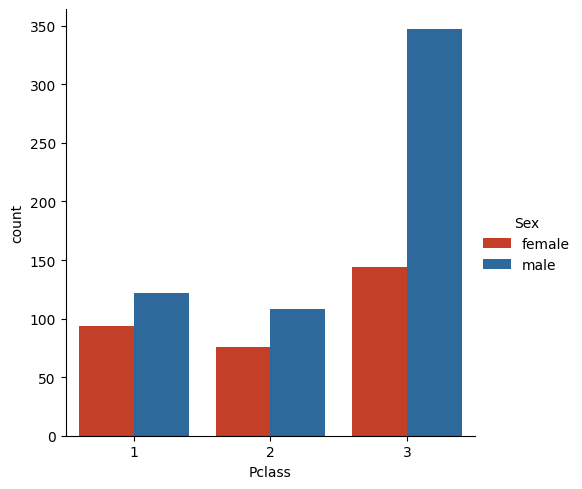

In [7]:
# Visualization
custom_colors = ["#DD2D0E", "#1B6BAC", "#C504BB"]
sns.catplot(data=train_data, x='Sex',  kind='count', palette = custom_colors)
# sns.catplot(data=train_cleared, x='Pclass', hue='Sex', kind='count', palette = custom_colors)
sns.catplot(data=train_data, x = 'Pclass', hue='Sex', kind='count', palette = custom_colors)

1) Больше мужчин, чем женщин
2) Мужчин в "бедных" каютах в ~2 раза больше чем женщин. В других классах ситуация примерно равная.

/tmp/ipykernel_31934/2513045823.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x = 'Pclass', hue='Survived', kind='count', palette = custom_colors)


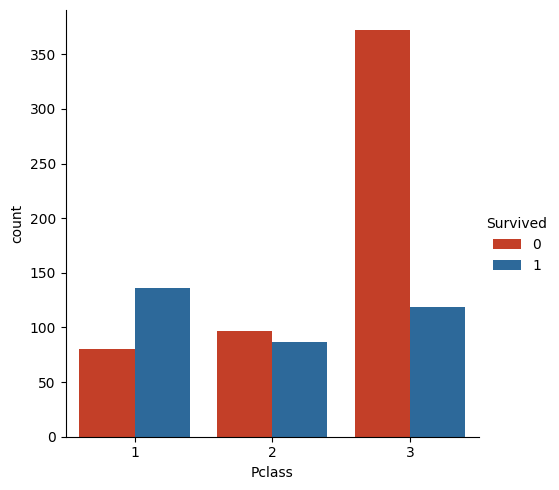

In [8]:
sns.catplot(data=train_data, x = 'Pclass', hue='Survived', kind='count', palette = custom_colors)

Процент выживших гораздо больше в 1 и 2 классе. Значит эти признаки преобладают

/tmp/ipykernel_31934/664206132.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x = 'br_sister_partner', hue='Survived', kind='count', palette = custom_colors)
/tmp/ipykernel_31934/664206132.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x = 'parents_childs', hue='Survived', kind='count', palette = custom_colors)


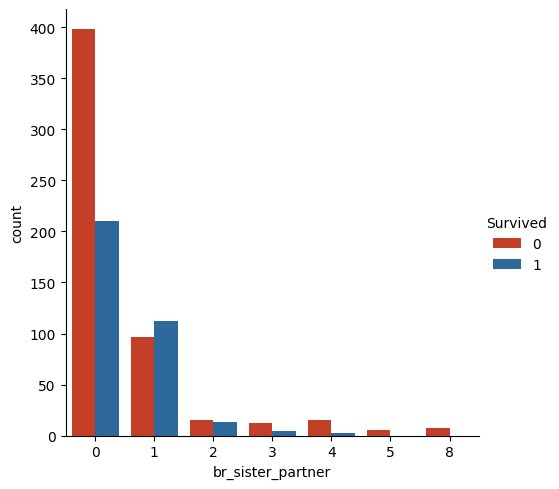

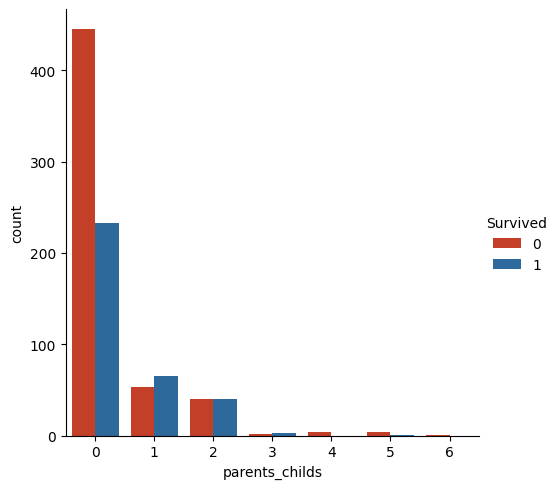

In [9]:
sns.catplot(data=train_data, x = 'br_sister_partner', hue='Survived', kind='count', palette = custom_colors)
sns.catplot(data=train_data, x = 'parents_childs', hue='Survived', kind='count', palette = custom_colors)

При отсутствии родственников больший процент умирал. Видимо, они спасали друг друга. При большой семье выживало меньшинство (1-2 человека)

/tmp/ipykernel_31934/3328233829.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_data, x = 'Sex', hue='Survived', kind='count', palette = custom_colors)


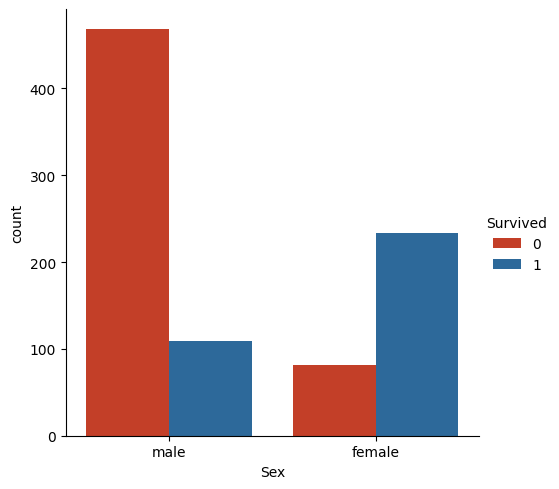

In [10]:
sns.catplot(data=train_data, x = 'Sex', hue='Survived', kind='count', palette = custom_colors)

В процентах мужчин погибло гораздо больше чем женщин (то есть женщин спасали первоочерёдно).

## Encoding

In [11]:
train_copy = train_data.copy()
test_copy = test_data.copy()

# Pclass encoding
mean_target_Pclass = train_copy.groupby('Pclass')['Survived'].mean()

mapping_pclass = mean_target_Pclass.to_dict()

train_copy['encoded_Pclass'] = train_copy['Pclass'].map(mapping_pclass)
test_copy['encoded_Pclass'] = test_copy['Pclass'].map(mapping_pclass)

# Попробую без удаление ординарного признака. Это может добавить инфоормативности.
# train_copy.drop(['Pclass'], axis=1, inplace=True)
# test_copy.drop(['Pclass'], axis=1, inplace=True)

In [12]:
# Sex encoding
encode_columns = ['port_name', 'Sex']

# добавлю таргет энкодинг для двух признаков
mapping_sex = train_copy.groupby('Sex')['Survived'].mean()
train_copy['sex_target_enc'] = train_copy['Sex'].map(mapping_sex)
test_copy['sex_target_enc'] = test_copy['Sex'].map(mapping_sex)

# mapping_f_num = train_copy.groupby('family_num')['Survived'].mean()
# train_copy['f_num_target_enc'] = train_copy['family_num'].map(mapping_f_num)
# test_copy['f_num_target_enc'] = test_copy['family_num'].map(mapping_f_num)

train_copy = pd.get_dummies(train_copy, columns=encode_columns, drop_first=True)
test_copy = pd.get_dummies(test_copy, columns=encode_columns, drop_first=True)

test_copy[['port_name_Q', 'port_name_S', 'Sex_male']] = test_copy[['port_name_Q', 'port_name_S', 'Sex_male']].astype(int)
train_copy[['port_name_Q', 'port_name_S', 'Sex_male']] = train_copy[['port_name_Q', 'port_name_S', 'Sex_male']].astype(int)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_copy.loc[:, ['Age', 'ticket_cost']] = scaler.fit_transform(train_copy.loc[:, ['Age', 'ticket_cost']]) 
test_copy.loc[:, ['Age', 'ticket_cost']] = scaler.fit_transform(test_copy.loc[:, ['Age', 'ticket_cost']])

In [ ]:
test_copy

In [14]:
X_train = train_copy.drop(['Survived'], axis=1)
y_train = train_copy['Survived']

X_test = test_copy.drop(['Survived'], axis=1)
y_test = test_copy['Survived']

### Логистическая регрессия

In [15]:
from sklearn.linear_model import LogisticRegression

model_logistic_regr = LogisticRegression(penalty='l2', 
                                         max_iter=1000, 
                                         C=1.5)
model_logistic_regr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model_logistic_regr.predict(X_test)

### SVM RBF

In [60]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', C=1.8)
model_svm.fit(X_train, y_train)

,C,1.8
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
y_pred = model_svm.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Acc = {accuracy}", '\n')
print(f"Recall = {recall_score(y_test, y_pred)}", '\n')
print(f"Precision = {precision_score(y_test, y_pred)}", '\n')

Acc = 0.9521531100478469 

Recall = 0.9407894736842105 

Precision = 0.9285714285714286 



In [63]:
def make_prediction_csv(prediction, test_data, filename='preds.csv', dirname='predictions'):
    if not os.path.exists(dirname):
        os.mkdir(dirname)
    save_path = os.path.join(dirname, filename)

    predictions_df = pd.DataFrame({'PassengerId': test_data.reset_index()['PassengerId'] ,'Survived': prediction})
    predictions_csv = predictions_df.to_csv(save_path, index=False)
    return predictions_csv

make_prediction_csv(prediction=y_pred, test_data=test_copy.reset_index()['PassengerId'])
    